# Exploratory Data Analysis — Opinion Survey (Assignment 1)

Survey of 96 respondents on 60 statements across four categories:
- **T** — Technology (T01–T15)
- **E** — Education (E01–E15)
- **S** — Ethics/Society (S01–S15)
- **V** — Environment (V01–V15)

Each response is a 5-point Likert scale value. This notebook explores the raw data
before we move on to constructing an opinion network from it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 1. Load the data

In [2]:
df = pd.read_csv("Survey_Results_UC.csv", encoding="utf-8-sig")
df = df.rename(columns={"id. Response ID": "respondent_id"})
df = df.set_index("respondent_id")

print(f"Respondents: {df.shape[0]}, Statements: {df.shape[1]}")
df.head()

Respondents: 96, Statements: 60


,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.,T07. Robots should replace humans in hazardous occupations whenever possible.,T08. AI-assisted diagnosis should become routine in healthcare.,T09. Autonomous vehicles will ultimately make transportation safer.,T10. Protection of personal data is more important than technological convenience.,T11. Technology companies should explain how recommendation algorithms work.,T12. Governments should introduce stricter regulations for Artificial Intelligence.,T13. Cybersecurity deserves greater investment than the development of new digital technologies.,T14. Social media algorithms contribute to opinion polarization.,T15. Society will increasingly depend on AI-assisted decision making.,E01. Project-based learning develops deeper understanding than examination-oriented learning.,E02. Traditional written examinations accurately measure a student's knowledge.,E03. Class attendance should be compulsory for all courses.,E04. High-quality online learning can effectively complement classroom teaching.,E05. Students should be encouraged to take courses outside their primary discipline.,E06. Every undergraduate student should participate in at least one research project.,"E07. Publishing research before graduation should be encouraged, but not mandatory.",E08. Maintaining academic honesty is more important than obtaining high grades.,E09. Collaborative learning is generally more effective than individual learning.,E10. Universities should prioritize innovation and problem-solving over rote learning.,E11. University curricula should be updated more frequently to match emerging technologies.,E12. Artificial intelligence should be integrated into teaching and personalized learning.,E13. Universities should invest more resources in research than in expanding infrastructure.,E14. Strong collaborations between universities and industry improve student education.,E15. Continuous learning and skill development are essential throughout one's career.,S01. Every individual has a responsibility to contribute positively to society.,S02. Universities should encourage students to participate in community service activities.,S03. New technologies should be evaluated for their societal impact before widespread deployment.,S04. Technology companies should be accountable for unethical use of their platforms.,S05. Individuals should have greater control over how their personal data are collected and used.,"S06. Combating online misinformation requires shared responsibility among users, platforms, and governments.",S07. Equal opportunities should be prioritized regardless of a person's background.,S08. Diverse teams generally make better decisions than homogeneous teams.,S09. Universities should promote an inclusive environment where different viewpoints can be discussed respectfully.,S10. Scientific evidence should play an important role in public policy decisions.,S11. People should be free to express differing opinions as long as they do not promote harm or discrimination.,S12. Young people should actively participate in addressing societal challenges.,S13. Critical evaluation of online information should be taught as a core educational skill.,S14. Leaders should prioritize ethical decision-making even when it reduces short-term gains.,S15. Building public trust is essential for responsible adoption of emerging technologies.,V01. Climate change requires immediate global action.,V02. Governments should prioritize investment in renewable energy over fossil fuels.,V03. Individuals should actively reduce

In [3]:
# Category of each statement, derived from its column prefix (T/E/S/V)
category_map = {col: col[0] for col in df.columns}
category_names = {"T": "Technology", "E": "Education", "S": "Ethics/Society", "V": "Environment"}

statement_cols = list(df.columns)
categories = pd.Series(category_map)
categories.value_counts()

T    15
E    15
S    15
V    15
Name: count, dtype: int64

## 2. Missing / non-standard values

Check for blanks and any responses outside the expected 5-point Likert set.

In [4]:
all_values = pd.unique(df.values.ravel())
print("Distinct raw values:", sorted(v for v in all_values if pd.notna(v)))

missing_or_nonstandard = df.isin(["", "No Comments"]) | df.isna()
print("\nCells missing / non-standard (blank or 'No Comments'):", missing_or_nonstandard.values.sum())

per_respondent_missing = missing_or_nonstandard.sum(axis=1)
per_respondent_missing[per_respondent_missing > 0].sort_values(ascending=False)

Distinct raw values: ['Agree', 'Disagree', 'Neutral', 'No Comments', 'Strongly Agree', 'Strongly Disagree']

Cells missing / non-standard (blank or 'No Comments'): 542


respondent_id
68     60
44     60
60     60
73     60
78     60
77     45
39     45
30     45
87     45
79     15
123    10
120     4
125     4
92      4
42      3
81      3
24      3
40      2
103     2
93      2
95      2
102     2
19      1
12      1
69      1
32      1
84      1
118     1
dtype: int64

## 3. Encode Likert responses numerically

Map the ordinal scale to integers -2..+2 so we can compute means, correlations, and
distances. Missing/non-standard values become `NaN`.

In [5]:
likert_map = {
    "Strongly Disagree": -2,
    "Disagree": -1,
    "Neutral": 0,
    "Agree": 1,
    "Strongly Agree": 2,
}

df_num = df.replace({"": np.nan, "No Comments": np.nan}).replace(likert_map)
df_num = df_num.apply(pd.to_numeric)

print(f"NaN cells after encoding: {df_num.isna().values.sum()} "
      f"({df_num.isna().values.mean():.2%} of all cells)")
df_num.describe().T.head()

NaN cells after encoding: 542 (9.41% of all cells)


,count,mean,std,min,25%,50%,75%,max
T01. Artificial Intelligence will improve society more than it will create problems.,91.0,0.637363,0.983378,-2.0,0.0,1.0,1.0,2.0
T02. Generative AI tools should be allowed as learning aids in higher education.,91.0,1.000000,0.988826,-2.0,1.0,1.0,2.0,2.0
T03. Students should disclose the use of AI in assignments and reports.,89.0,1.011236,0.846039,-2.0,1.0,1.0,2.0,2.0
T04. Every engineering student should receive formal education in AI.,91.0,1.208791,0.836879,-2.0,1.0,1.0,2.0,2.0
T05. Artificial Intelligence will significantly accelerate scientific discovery.,91.0,1.186813,0.905687,-2.0,1.0,1.0,2.0,2.0


## 4. Overall response distribution

How often is each Likert option chosen, overall and broken down by category?

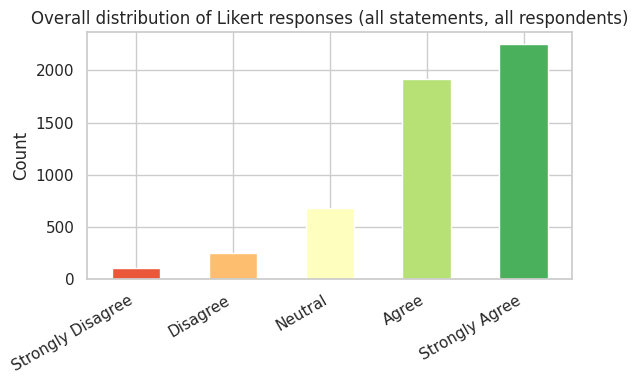

In [6]:
order = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
counts = df.replace({"": np.nan, "No Comments": np.nan}).stack().value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=sns.color_palette("RdYlGn", len(order)))
ax.set_ylabel("Count")
ax.set_title("Overall distribution of Likert responses (all statements, all respondents)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_349486/2416611578.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


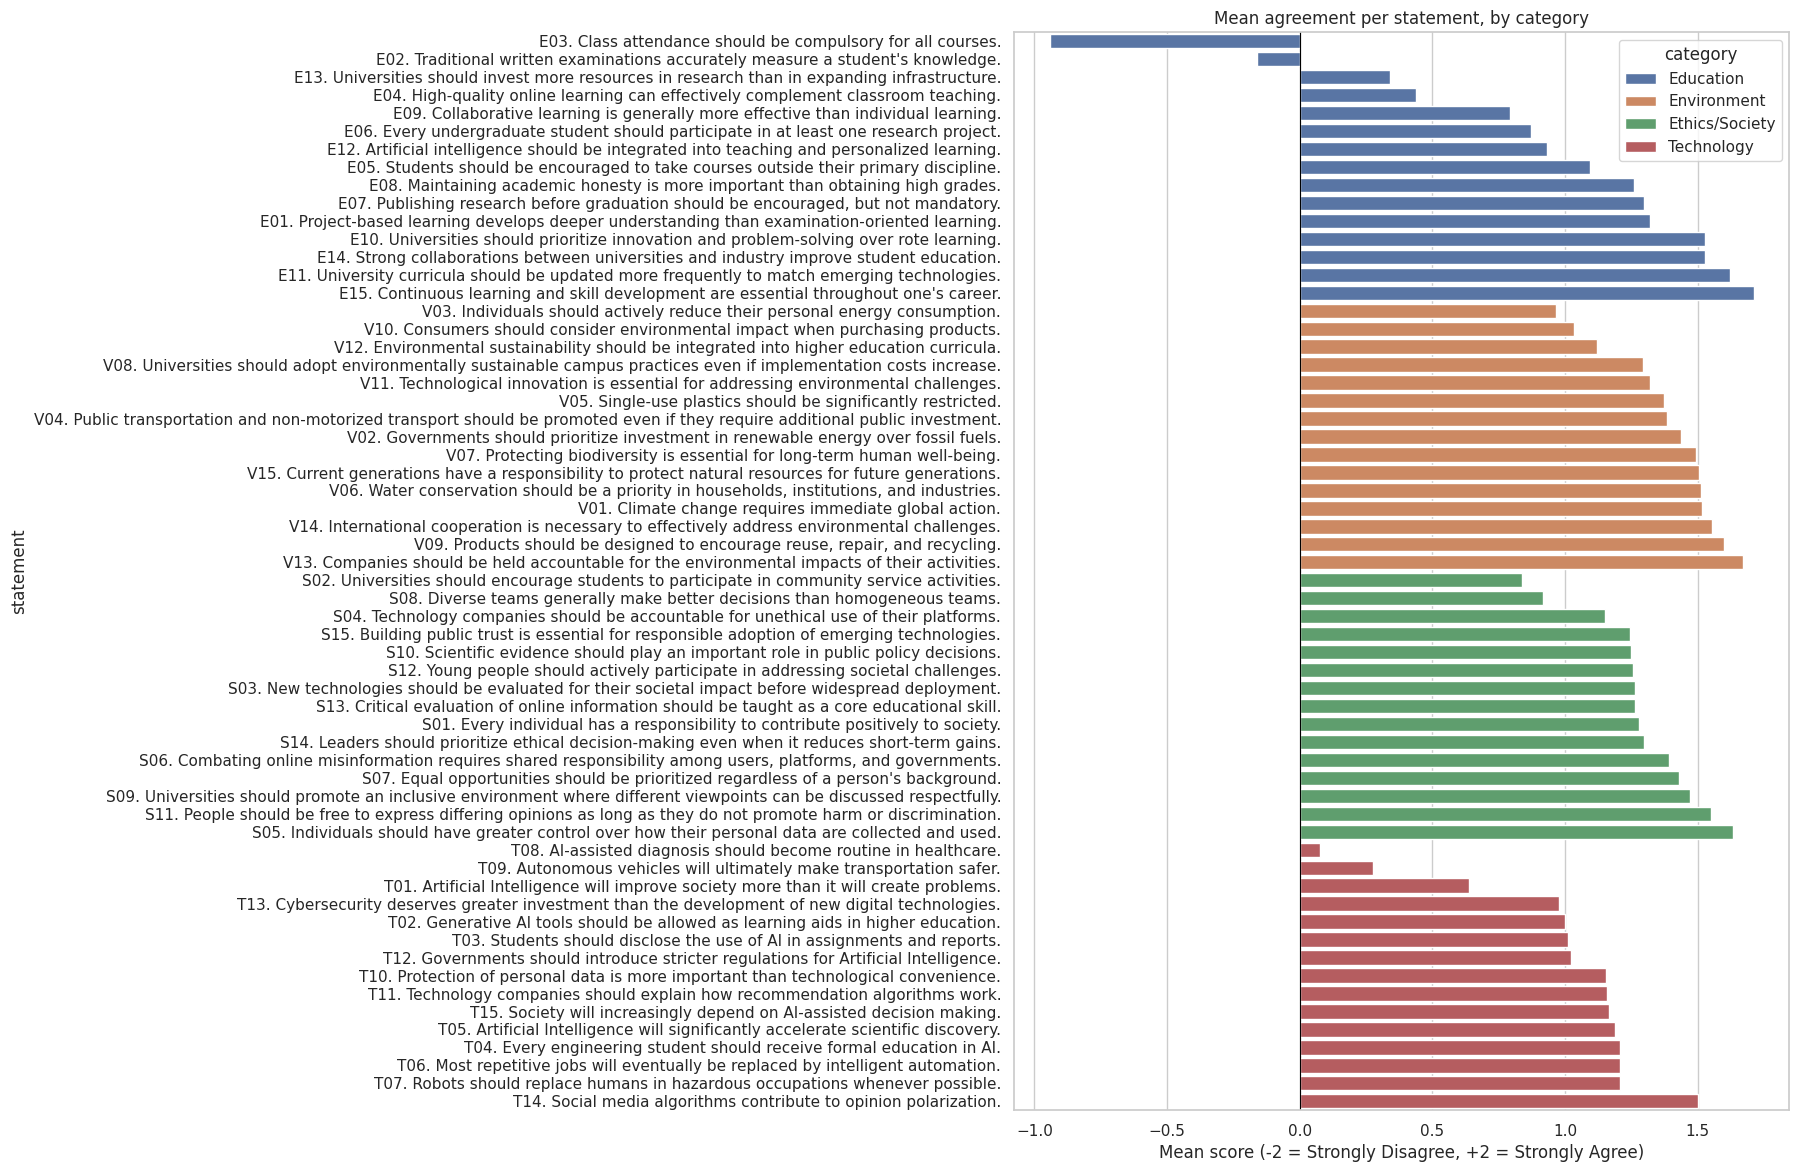

In [7]:
# Mean agreement (-2..+2) per statement, grouped by category
statement_means = df_num.mean(axis=0).rename("mean_score").to_frame()
statement_means["category"] = statement_means.index.map(category_map).map(category_names)

fig, ax = plt.subplots(figsize=(10, 14))
order_statements = statement_means.sort_values(["category", "mean_score"]).index
sns.barplot(
    data=statement_means.loc[order_statements].reset_index(names="statement"),
    y="statement", x="mean_score", hue="category", dodge=False, ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean score (-2 = Strongly Disagree, +2 = Strongly Agree)")
ax.set_title("Mean agreement per statement, by category")
plt.tight_layout()
plt.show()

## 5. Respondent-level summary

For each respondent, average their (numeric) opinion within each of the four categories.
This 96×4 matrix is a compact summary of "where everyone stands" and a natural feature
set for later network construction (e.g. edges from respondent similarity).

In [8]:
category_scores = pd.DataFrame({
    cat_letter: df_num.loc[:, categories == cat_letter].mean(axis=1)
    for cat_letter in category_names
}).rename(columns=category_names)

category_scores.head()

,Technology,Education,Ethics/Society,Environment
respondent_id,,,,
11,0.800000,0.800000,0.933333,0.533333
12,0.533333,0.933333,0.571429,0.800000
13,0.933333,1.066667,1.333333,1.666667
14,0.800000,0.600000,1.133333,1.200000
16,1.200000,0.666667,1.266667,1.266667


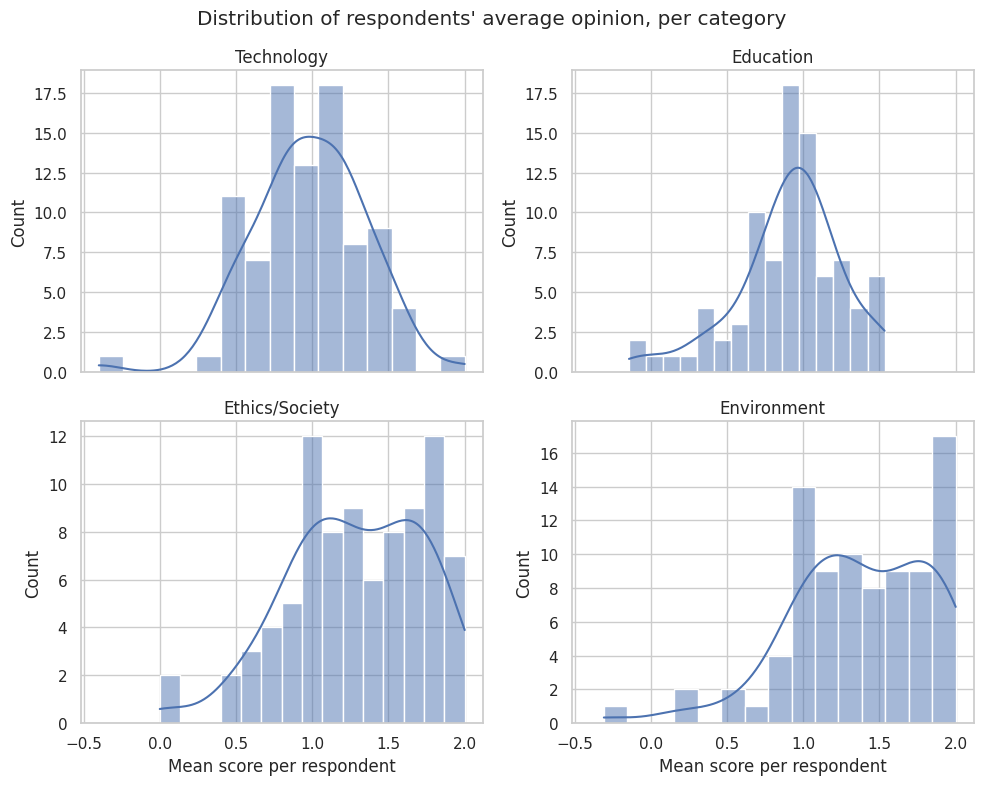

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for ax, cat in zip(axes.ravel(), category_scores.columns):
    sns.histplot(category_scores[cat], bins=15, kde=True, ax=ax)
    ax.set_title(cat)
    ax.set_xlabel("Mean score per respondent")
fig.suptitle("Distribution of respondents' average opinion, per category")
plt.tight_layout()
plt.show()

## 6. Correlation between statements

Pairwise correlation of the 60 statements shows which opinions tend to move together
(useful for spotting redundant statements or latent sub-topics within a category).

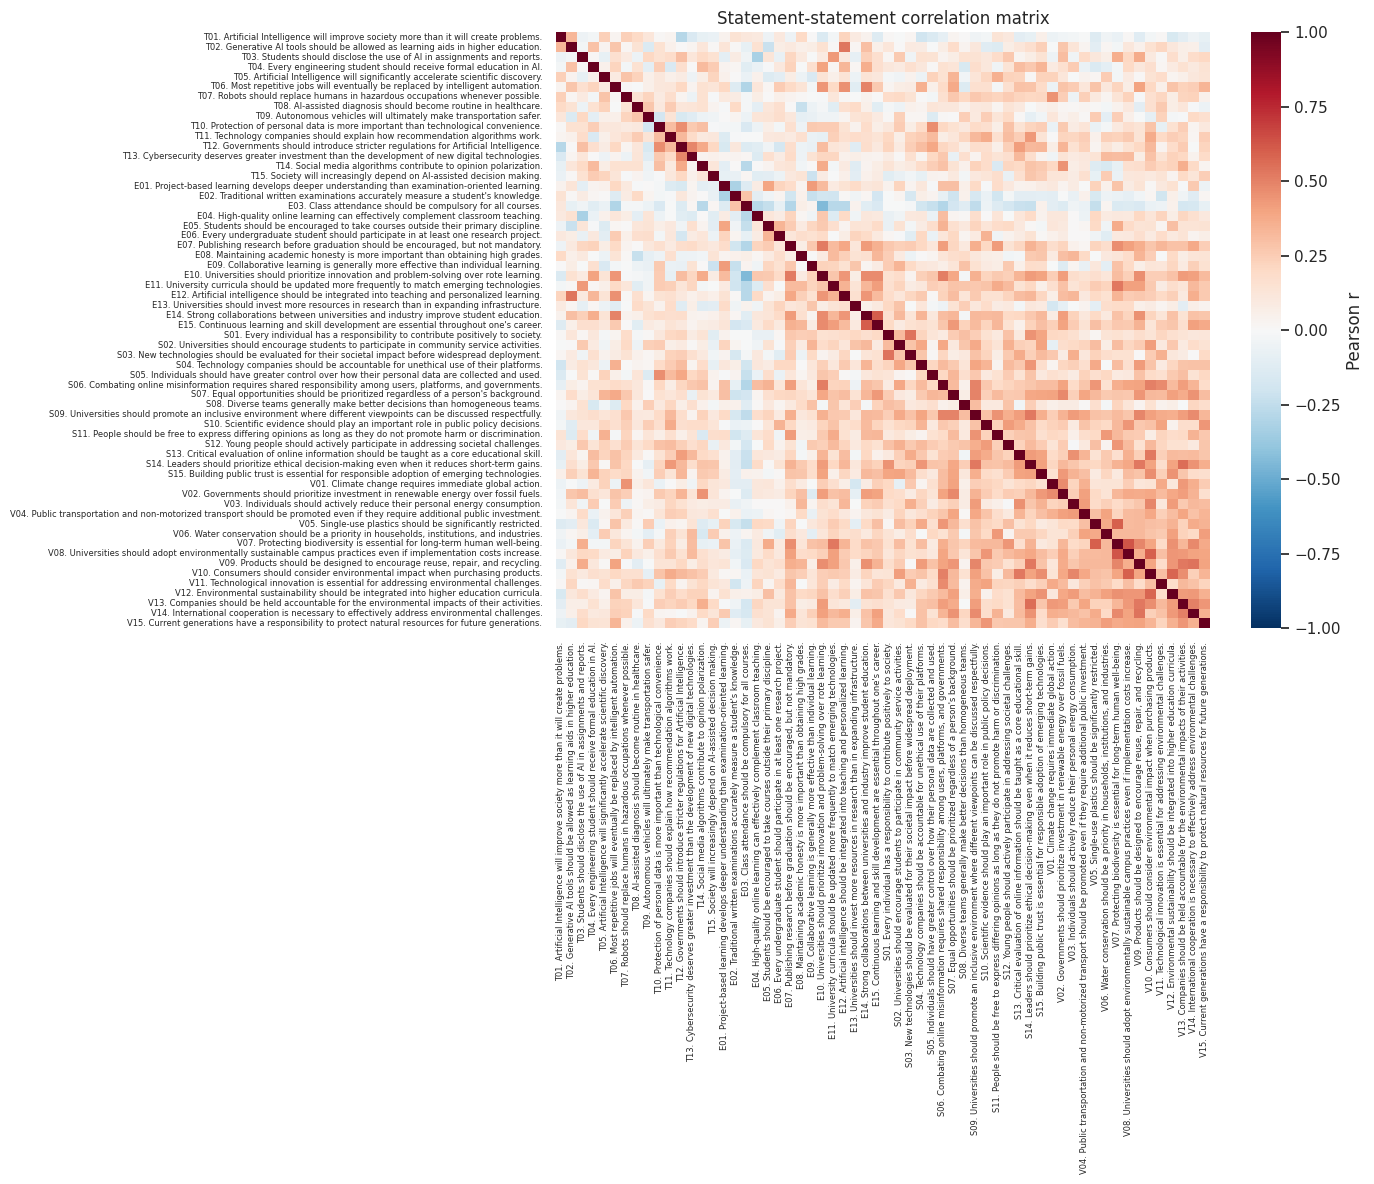

In [10]:
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            xticklabels=True, yticklabels=True, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Statement-statement correlation matrix")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

In [11]:
# Most correlated statement pairs (excluding self-correlation), useful to sanity-check
# that "similar" statements really do co-vary
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("r")
    .sort_values(key=abs, ascending=False)
)
corr_pairs.head(15)

V07. Protecting biodiversity is essential for long-term human well-being.                                            V08. Universities should adopt environmentally sustainable campus practices even if implementation costs increase.    0.629563
E14. Strong collaborations between universities and industry improve student education.                              E15. Continuous learning and skill development are essential throughout one's career.                                 0.604181
V05. Single-use plastics should be significantly restricted.                                                         V07. Protecting biodiversity is essential for long-term human well-being.                                             0.601139
V08. Universities should adopt environmentally sustainable campus practices even if implementation costs increase.   V10. Consumers should consider environmental impact when purchasing products.                                         0.599421
V10. Consumers should co

## 7. Respondent-respondent similarity

For the opinion network we'll eventually build, nodes are respondents and edges will
likely come from how similar two respondents' opinions are. As a preview, compute
pairwise similarity across all 60 statements (Pearson correlation between respondents'
answer vectors, pairwise-complete) and look at its distribution.

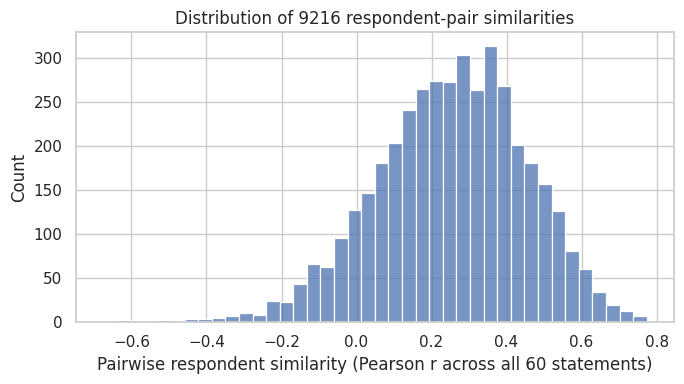

count    4091.000000
mean        0.252102
std         0.200170
min        -0.676084
25%         0.121913
50%         0.263331
75%         0.393101
max         0.773922
dtype: float64

In [12]:
respondent_sim = df_num.T.corr()  # 96x96 Pearson correlation between respondents

sim_values = respondent_sim.where(
    np.triu(np.ones(respondent_sim.shape), k=1).astype(bool)
).stack()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(sim_values, bins=40, ax=ax)
ax.set_xlabel("Pairwise respondent similarity (Pearson r across all 60 statements)")
ax.set_title(f"Distribution of {len(sim_values)} respondent-pair similarities")
plt.tight_layout()
plt.show()

sim_values.describe()

## 8. Low-dimensional view of respondents (PCA)

Project each respondent's 60-dimensional answer vector down to 2 components to see
whether visible clusters of opinion already emerge before any network is built.

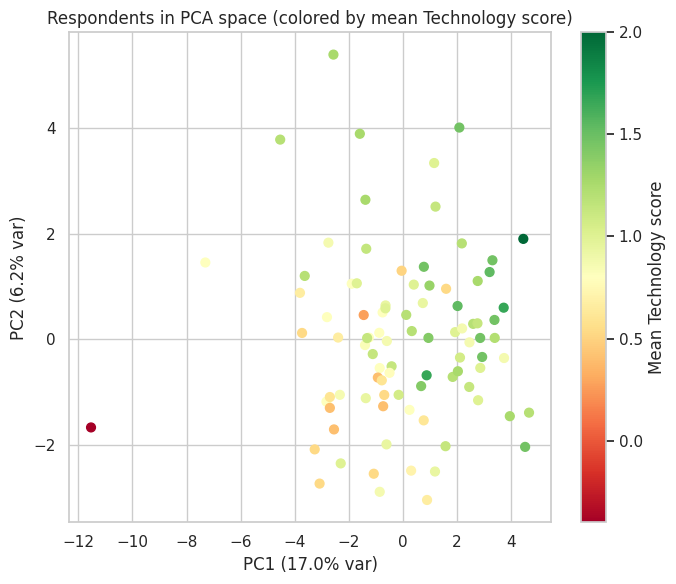

In [13]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

X = SimpleImputer(strategy="mean").fit_transform(df_num.values)
pcs = PCA(n_components=2, random_state=0).fit(X)
X_pca = pcs.transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=category_scores["Technology"], cmap="RdYlGn", s=40)
ax.set_xlabel(f"PC1 ({pcs.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pcs.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("Respondents in PCA space (colored by mean Technology score)")
plt.colorbar(sc, label="Mean Technology score")
plt.tight_layout()
plt.show()

## 9. Internal consistency per category (Cronbach's alpha)

A standard check for Likert-scale surveys: do the 15 items grouped under each category
(Technology/Education/Ethics-Society/Environment) actually "hang together" as a coherent
construct? Cronbach's alpha close to 1 means the items within a category are highly
inter-correlated (respondents who agree with one tend to agree with the others); a low
alpha means the category label doesn't correspond to a single underlying opinion
dimension, which matters for how we'll aggregate/weight statements in the network.

In [14]:
def cronbach_alpha(items: pd.DataFrame) -> float:
    items = items.dropna()
    k = items.shape[1]
    item_vars = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alphas = {
    category_names[cat]: cronbach_alpha(df_num.loc[:, categories == cat])
    for cat in category_names
}
pd.Series(alphas, name="Cronbach's alpha").sort_values(ascending=False)

Environment       0.867681
Ethics/Society    0.824263
Technology        0.648720
Education         0.578696
Name: Cronbach's alpha, dtype: float64

## 10. Consensus vs. controversy per statement

Another standard survey analysis: which statements does everyone agree on (low
variance, "consensus" items) vs. which ones genuinely split the group (high variance,
often bimodal — a cluster of Agree and a cluster of Disagree rather than everyone at
Neutral)? Controversial statements are natural candidates for edges that separate
opinion communities in the network; consensus statements contribute little to
differentiating respondents.

We use standard deviation as a simple polarization proxy, and a bimodality coefficient
(`BC`) to distinguish "controversial" (bimodal, two opposed camps) from merely "mixed"
(uniformly spread) statements. `BC > 0.555` is the common Sarle's-bimodality-coefficient
threshold for likely bimodality.

In [15]:
from scipy.stats import skew, kurtosis

def bimodality_coefficient(x):
    x = x.dropna()
    n = len(x)
    g = skew(x, bias=False)
    k = kurtosis(x, fisher=True, bias=False)  # excess kurtosis
    return (g**2 + 1) / (k + 3 * (n - 1) ** 2 / ((n - 2) * (n - 3)))

polarization = pd.DataFrame({
    "std": df_num.std(axis=0),
    "bimodality_coef": df_num.apply(bimodality_coefficient, axis=0),
})
polarization["category"] = polarization.index.map(category_map).map(category_names)
polarization["likely_bimodal"] = polarization["bimodality_coef"] > 0.555

print("Most controversial (highest std) statements:")
display(polarization.sort_values("std", ascending=False).head(8))

print("\nMost consensual (lowest std) statements:")
display(polarization.sort_values("std", ascending=True).head(8))

print(f"\nStatements flagged as likely bimodal: {polarization['likely_bimodal'].sum()} / {len(polarization)}")
polarization[polarization["likely_bimodal"]].sort_values("bimodality_coef", ascending=False)

Most controversial (highest std) statements:


,std,bimodality_coef,category,likely_bimodal
E04. High-quality online learning can effectively complement classroom teaching.,1.168393,0.517803,Education,False
E03. Class attendance should be compulsory for all courses.,1.124322,0.582112,Education,True
E02. Traditional written examinations accurately measure a student's knowledge.,1.119318,0.454180,Education,False
T08. AI-assisted diagnosis should become routine in healthcare.,1.093677,0.417941,Technology,False
S02. Universities should encourage students to participate in community service activities.,1.055149,0.528297,Ethics/Society,False
E09. Collaborative learning is generally more effective than individual learning.,1.041676,0.460652,Education,False
T07. Robots should replace humans in hazardous occupations whenever possible.,1.038337,0.653590,Technology,True
E12. Artificial intelligence should be integrated into teaching and personalized learning.,1.031967,0.536707,Education,False



Most consensual (lowest std) statements:


,std,bimodality_coef,category,likely_bimodal
E15. Continuous learning and skill development are essential throughout one's career.,0.503662,0.729028,Education,True
V13. Companies should be held accountable for the environmental impacts of their activities.,0.564595,0.586884,Environment,True
S09. Universities should promote an inclusive environment where different viewpoints can be discussed respectfully.,0.589355,0.534416,Ethics/Society,False
"V06. Water conservation should be a priority in households, institutions, and industries.",0.590977,0.577641,Environment,True
S05. Individuals should have greater control over how their personal data are collected and used.,0.592883,0.723629,Ethics/Society,True
S11. People should be free to express differing opinions as long as they do not promote harm or discrimination.,0.605376,0.504649,Ethics/Society,False
V01. Climate change requires immediate global action.,0.628902,0.635691,Environment,True
V15. Current generations have a responsibility to protect natural resources for future generations.,0.629125,0.498089,Environment,False



Statements flagged as likely bimodal: 17 / 60


,std,bimodality_coef,category,likely_bimodal
E15. Continuous learning and skill development are essential throughout one's career.,0.503662,0.729028,Education,True
S05. Individuals should have greater control over how their personal data are collected and used.,0.592883,0.723629,Ethics/Society,True
"V09. Products should be designed to encourage reuse, repair, and recycling.",0.710466,0.696368,Environment,True
E01. Project-based learning develops deeper understanding than examination-oriented learning.,0.908542,0.676347,Education,True
T07. Robots should replace humans in hazardous occupations whenever possible.,1.038337,0.653590,Technology,True
E11. University curricula should be updated more frequently to match emerging technologies.,0.633216,0.652296,Education,True
S07. Equal opportunities should be prioritized regardless of a person's background.,0.790245,0.637712,Ethics/Society,True
V01. Climate change requires immediate global action.,0.628902,0.635691,Environment,True
E14. Strong collaborations between universities and industry improve student education.,0.696154,0.611101,Education,True
T14. Social media algorithms contribute to opinion polarization.,0.768041,0.595264,Technology,True


## 11. Statement (item) network — a psychometric network preview

A common approach in attitude/opinion research (and directly relevant to this course)
is to treat the *statements themselves* as nodes of a network, with edges weighted by
how correlated respondents' answers to them are ("psychometric networks" / attitude
networks). Building this now, before the final respondent network, lets us:

- Sanity-check the a-priori T/E/S/V categories against communities **detected purely
  from the data** (do items cluster the way the survey designer intended?).
- Identify "bridge" statements that connect otherwise separate topics.

We threshold the statement-correlation matrix from Section 6 (`|r| >= 0.3`) to keep
only meaningful edges, run Louvain community detection, and compare against the known
T/E/S/V labels with the Adjusted Rand Index (1.0 = perfect agreement, 0 = random).

In [16]:
import networkx as nx
from networkx.algorithms.community import louvain_communities
from sklearn.metrics import adjusted_rand_score

ITEM_THRESHOLD = 0.3

G_items = nx.Graph()
G_items.add_nodes_from(statement_cols)
for i, a in enumerate(statement_cols):
    for b in statement_cols[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) >= ITEM_THRESHOLD:
            G_items.add_edge(a, b, weight=abs(r), sign=np.sign(r))

print(f"Item network: {G_items.number_of_nodes()} nodes, {G_items.number_of_edges()} edges "
      f"(threshold |r| >= {ITEM_THRESHOLD})")

item_communities = louvain_communities(G_items, weight="weight", seed=0)
item_community_of = {n: i for i, comm in enumerate(item_communities) for n in comm}
print(f"Detected {len(item_communities)} communities")

true_labels = [category_map[n] for n in G_items.nodes]
detected_labels = [item_community_of[n] for n in G_items.nodes]
print(f"Adjusted Rand Index vs. a-priori T/E/S/V categories: {adjusted_rand_score(true_labels, detected_labels):.3f}")

Item network: 60 nodes, 316 edges (threshold |r| >= 0.3)
Detected 9 communities
Adjusted Rand Index vs. a-priori T/E/S/V categories: 0.234


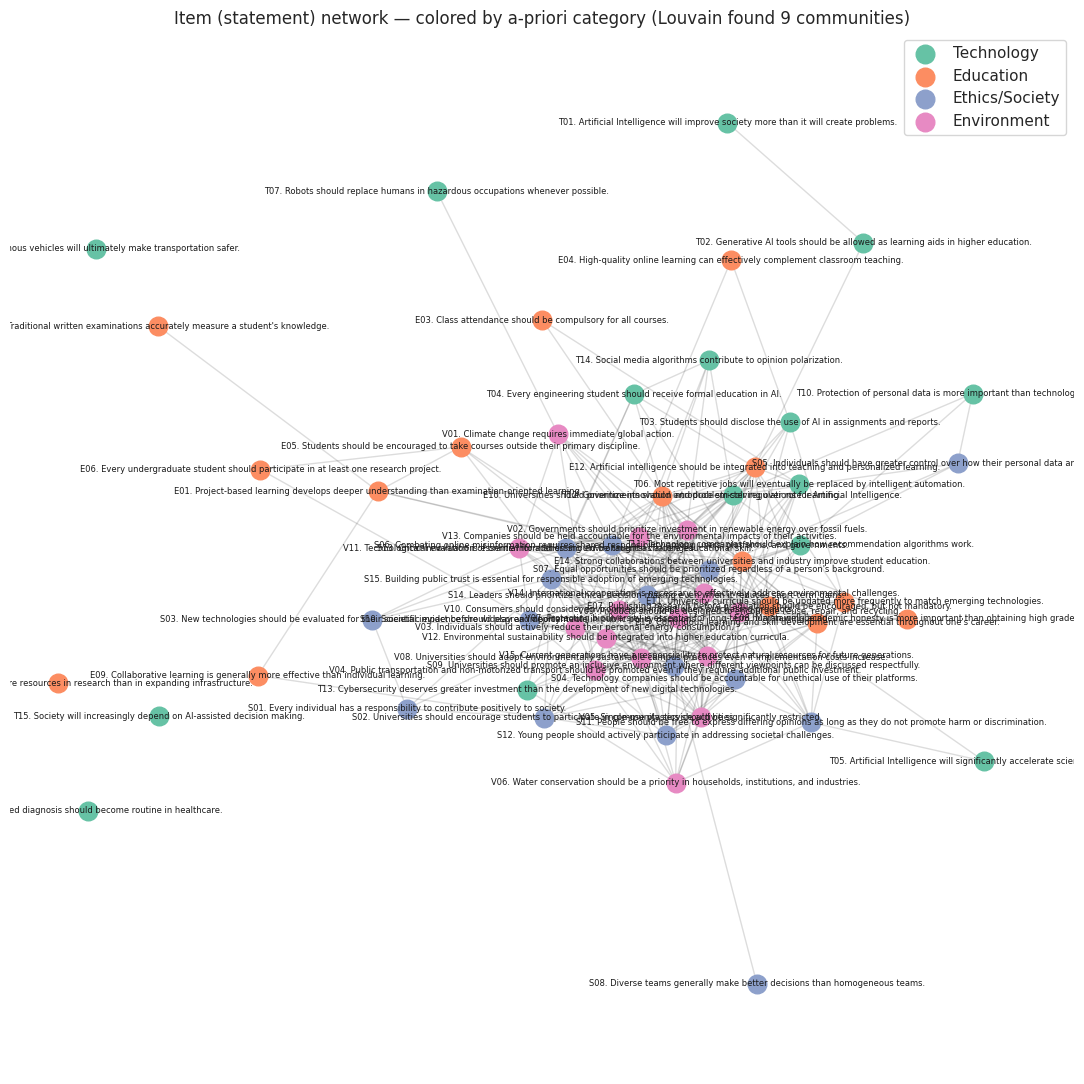

In [17]:
palette = sns.color_palette("Set2", len(category_names))
cat_color = {cat: palette[i] for i, cat in enumerate(category_names)}

pos = nx.spring_layout(G_items, weight="weight", seed=0, k=0.4)
fig, ax = plt.subplots(figsize=(11, 11))

nx.draw_networkx_edges(G_items, pos, alpha=0.15, ax=ax)
for cat, name in category_names.items():
    nodes = [n for n in G_items.nodes if category_map[n] == cat]
    nx.draw_networkx_nodes(G_items, pos, nodelist=nodes, node_color=[cat_color[cat]],
                            node_size=180, label=name, ax=ax)
nx.draw_networkx_labels(G_items, pos, font_size=6, ax=ax)
ax.set_title(f"Item (statement) network — colored by a-priori category (Louvain found "
             f"{len(item_communities)} communities)")
ax.legend(scatterpoints=1)
ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Respondent similarity network — preview of the target network

This is the network-science core of the assignment: nodes = respondents, edges = pairwise
opinion similarity from Section 7 (Pearson correlation across all 60 statements). We keep
edges above a threshold (a common, simple way to turn a dense similarity matrix into a
sparse graph — equivalent to a correlation-based "backbone") and compute the usual
first-pass network diagnostics:

- **density / average degree** — how densely connected the opinion space is,
- **degree distribution** — whether a few respondents are unusually central "hubs",
- **connected components** — whether opinions are one cohesive network or split into
  isolated islands at this threshold,
- **clustering coefficient** — local triadic closure (do a respondent's "similar"
  neighbors also tend to be similar to each other?),
- **centrality** (degree, betweenness, eigenvector) — who holds the most "typical"/
  consensus opinions (central) vs. more idiosyncratic ones (peripheral),
- **community detection** (Louvain) — candidate opinion sub-groups, cross-checked
  against the category-score / PCA view from Sections 5 and 8.

Note we deliberately keep the 5 respondents flagged as "trivial" in `Response_Quality_Check.ipynb`
in this network for now (per team decision) — their near-zero variance means Pearson
correlation with them is undefined/near-zero, so they should naturally end up isolated or
low-degree here rather than distorting it; that's itself worth checking below.

In [18]:
RESP_THRESHOLD = 0.4

G_resp = nx.Graph()
G_resp.add_nodes_from(df_num.index)
for i, a in enumerate(df_num.index):
    for b in df_num.index[i + 1:]:
        r = respondent_sim.loc[a, b]
        if pd.notna(r) and r >= RESP_THRESHOLD:
            G_resp.add_edge(a, b, weight=r)

n, m = G_resp.number_of_nodes(), G_resp.number_of_edges()
print(f"Respondent network: {n} nodes, {m} edges (threshold r >= {RESP_THRESHOLD})")
print(f"Density: {nx.density(G_resp):.3f}")
print(f"Average degree: {2 * m / n:.2f}")
print(f"Isolated nodes (degree 0): {sum(1 for _, d in G_resp.degree() if d == 0)}")

components = sorted(nx.connected_components(G_resp), key=len, reverse=True)
print(f"Connected components: {len(components)}, largest has {len(components[0])} nodes")

print(f"Average clustering coefficient: {nx.average_clustering(G_resp):.3f}")

Respondent network: 96 nodes, 957 edges (threshold r >= 0.4)
Density: 0.210
Average degree: 19.94
Isolated nodes (degree 0): 8
Connected components: 9, largest has 88 nodes
Average clustering coefficient: 0.510


### 12.1 Threshold sensitivity

The threshold above is an arbitrary choice — a core decision we'll need to justify in
the final report. Sweep it and look at how density, the giant component's size, and edge
count change, similar to a percolation curve; this helps pick a threshold that yields a
connected-but-sparse graph rather than either a single blob or a disconnected mess.

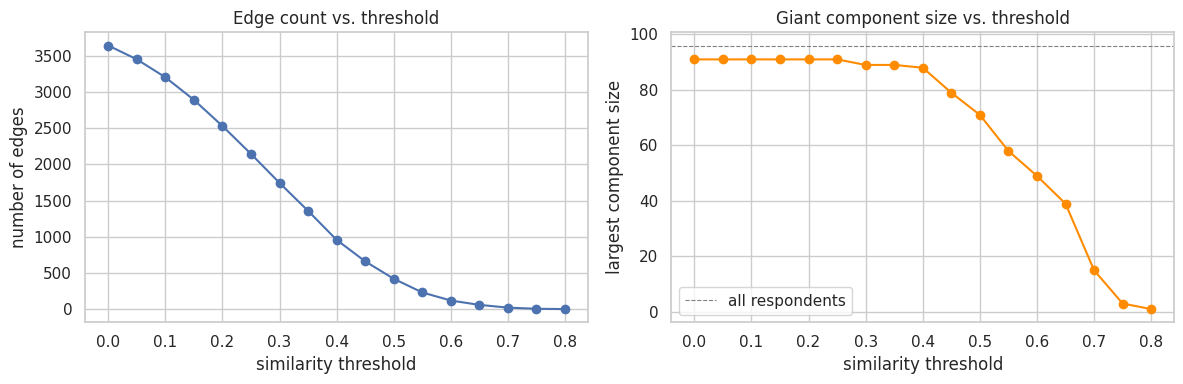

In [19]:
thresholds = np.arange(0.0, 0.81, 0.05)
sweep = []
sim_no_diag = respondent_sim.where(~np.eye(len(respondent_sim), dtype=bool))

for t in thresholds:
    edges = (sim_no_diag >= t).values.sum() // 2
    Gt = nx.Graph()
    Gt.add_nodes_from(df_num.index)
    Gt.add_edges_from(
        (a, b) for a in df_num.index for b in df_num.index
        if a < b and pd.notna(sim_no_diag.loc[a, b]) and sim_no_diag.loc[a, b] >= t
    )
    giant = len(max(nx.connected_components(Gt), key=len))
    sweep.append({"threshold": t, "edges": edges, "density": nx.density(Gt), "giant_component": giant})

sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep_df["threshold"], sweep_df["edges"], marker="o")
axes[0].set_xlabel("similarity threshold")
axes[0].set_ylabel("number of edges")
axes[0].set_title("Edge count vs. threshold")

axes[1].plot(sweep_df["threshold"], sweep_df["giant_component"], marker="o", color="darkorange")
axes[1].axhline(df_num.shape[0], color="gray", linestyle="--", linewidth=0.8, label="all respondents")
axes[1].set_xlabel("similarity threshold")
axes[1].set_ylabel("largest component size")
axes[1].set_title("Giant component size vs. threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

### 12.2 Degree distribution

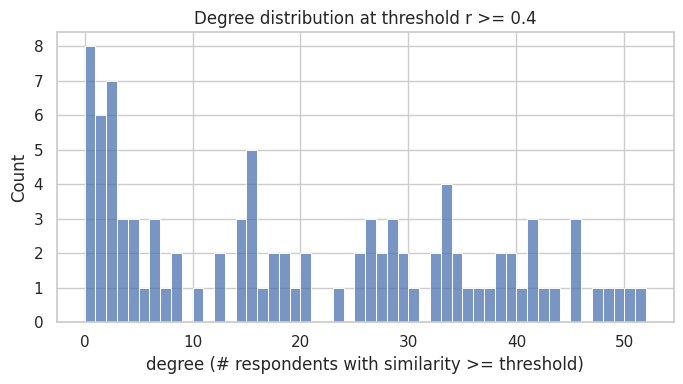

Highest-degree respondents (most 'typical'/consensus opinions at this threshold):


49     51
61     50
114    49
70     48
67     47
Name: degree, dtype: int64

In [20]:
degrees = pd.Series(dict(G_resp.degree()), name="degree")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(degrees, bins=range(0, degrees.max() + 2), ax=ax)
ax.set_xlabel("degree (# respondents with similarity >= threshold)")
ax.set_title(f"Degree distribution at threshold r >= {RESP_THRESHOLD}")
plt.tight_layout()
plt.show()

print("Highest-degree respondents (most 'typical'/consensus opinions at this threshold):")
degrees.sort_values(ascending=False).head(5)

### 12.3 Centrality

Degree, betweenness, and eigenvector centrality, computed on the largest connected
component only (centrality on disconnected graphs is otherwise ill-defined for
betweenness/eigenvector).

In [21]:
G_giant = G_resp.subgraph(components[0]).copy()

centrality = pd.DataFrame({
    "degree": nx.degree_centrality(G_giant),
    "betweenness": nx.betweenness_centrality(G_giant, weight="weight"),
    "eigenvector": nx.eigenvector_centrality(G_giant, weight="weight", max_iter=1000),
})

print(f"Centrality computed on the giant component ({G_giant.number_of_nodes()} nodes)")
centrality.sort_values("eigenvector", ascending=False).head(10)

Centrality computed on the giant component (88 nodes)


,degree,betweenness,eigenvector
114,0.563218,0.018712,0.208442
49,0.586207,0.063619,0.205486
61,0.574713,0.018177,0.204991
81,0.471264,0.001069,0.189171
104,0.517241,0.006950,0.188665
90,0.517241,0.035819,0.187521
67,0.540230,0.017642,0.186763
70,0.551724,0.045175,0.184908
55,0.517241,0.017910,0.181765
83,0.471264,0.008019,0.176003


### 12.4 Community detection and visualization

Run Louvain on the full respondent network to find candidate "opinion groups," then
visualize the network with nodes colored by detected community and sized by degree.
We also check whether communities correspond to any single category's score (e.g. is a
community just "people who like Technology") or cut across all four — the latter would
suggest opinion groups are driven by a more general ideological alignment rather than a
single topic.

In [22]:
resp_communities = louvain_communities(G_resp, weight="weight", seed=0)
resp_community_of = {n: i for i, comm in enumerate(resp_communities) for n in comm}
print(f"Detected {len(resp_communities)} communities "
      f"(sizes: {sorted((len(c) for c in resp_communities), reverse=True)})")

comm_series = pd.Series(resp_community_of, name="community")
print("\nMean category score by detected community:")
category_scores.join(comm_series).groupby("community")[list(category_names.values())].mean()

Detected 12 communities (sizes: [31, 24, 22, 11, 1, 1, 1, 1, 1, 1, 1, 1])

Mean category score by detected community:


,Technology,Education,Ethics/Society,Environment
community,,,,
0,0.933333,1.024176,1.425000,1.426984
1,NaN,NaN,NaN,NaN
2,1.156494,0.751701,1.322519,1.421429
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,0.869467,0.988462,1.248980,1.352381
8,1.266667,0.921212,1.248918,1.587879


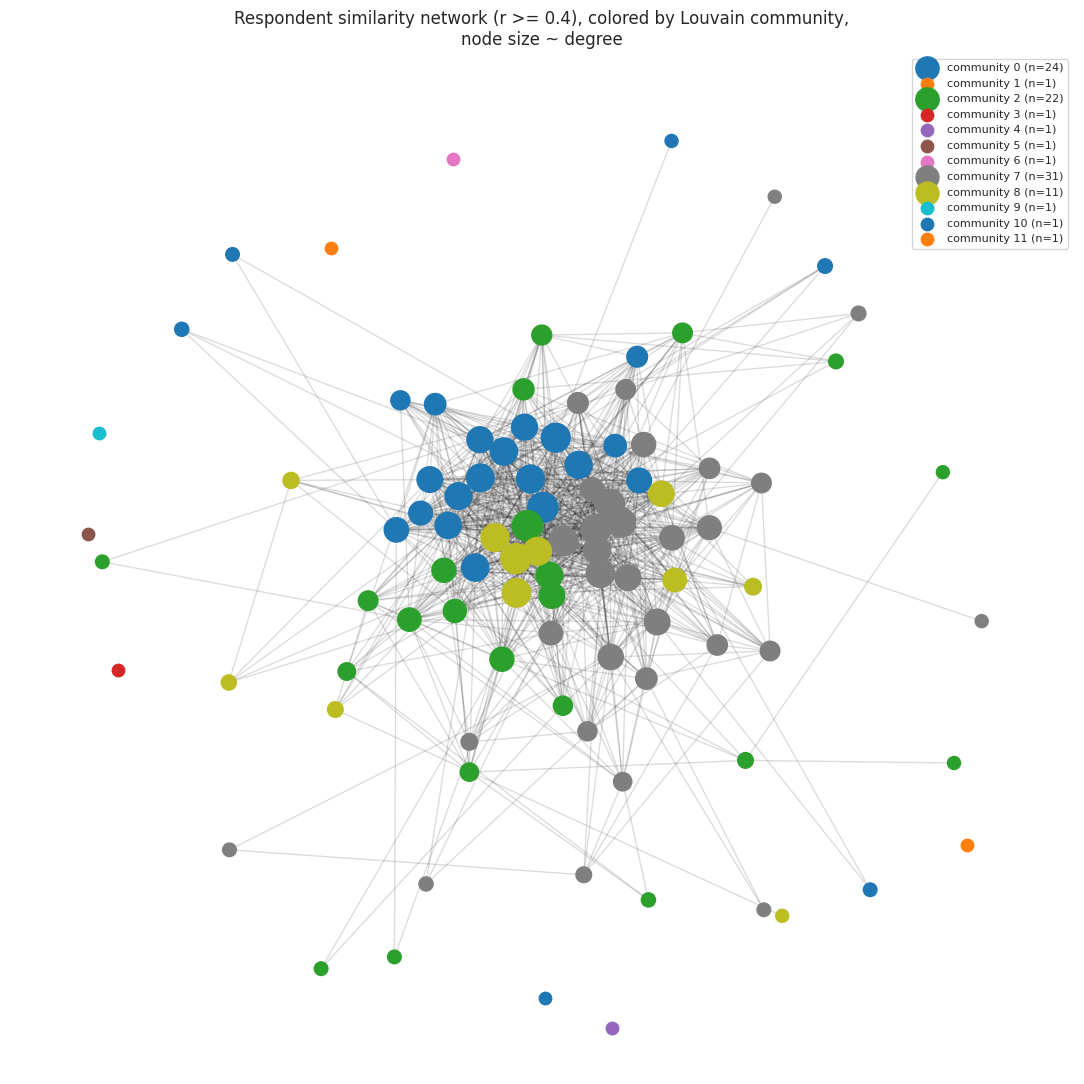

In [23]:
pos_resp = nx.spring_layout(G_resp, weight="weight", seed=0, k=0.6)
comm_palette = sns.color_palette("tab10", len(resp_communities))

fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(G_resp, pos_resp, alpha=0.15, ax=ax)
for i, comm in enumerate(resp_communities):
    sizes = [80 + 400 * degrees.get(n, 0) / max(degrees.max(), 1) for n in comm]
    nx.draw_networkx_nodes(G_resp, pos_resp, nodelist=list(comm), node_color=[comm_palette[i]],
                            node_size=sizes, label=f"community {i} (n={len(comm)})", ax=ax)
ax.set_title(f"Respondent similarity network (r >= {RESP_THRESHOLD}), colored by Louvain community,\n"
             "node size ~ degree")
ax.legend(scatterpoints=1, fontsize=8)
ax.axis("off")
plt.tight_layout()
plt.show()

### 12.5 Where do the flagged "trivial" respondents end up?

We chose to keep the 5 respondents flagged as potentially trivial/straight-lined in
`Response_Quality_Check.ipynb` (IDs 41, 90, 91, 94, 110) rather than remove them. Check
their degree in this network as a sanity check on the concern raised there — near-zero
variance should make their correlation with others small/undefined, so they should show
up as low-degree or isolated rather than as artificial hubs.

In [24]:
flagged_ids = [41, 90, 91, 94, 110]
print(f"Median degree overall: {degrees.median():.1f}")
degrees.loc[degrees.index.isin(flagged_ids)].rename("degree").to_frame().assign(
    percentile=lambda d: d["degree"].apply(lambda v: (degrees <= v).mean())
)

Median degree overall: 17.5


,degree,percentile
41,26,0.614583
90,45,0.947917
91,18,0.520833
94,28,0.666667
110,34,0.781250


## Summary

- 96 respondents, 60 Likert statements across Technology / Education / Ethics-Society / Environment.
- Missing/non-standard responses are rare — encoded as `NaN` after mapping to a -2..+2 scale.
- Opinions skew toward agreement overall, with category- and statement-level variation shown above.
- Cronbach's alpha per category checks whether the T/E/S/V groupings are internally
  consistent; the consensus/controversy (variance + bimodality) view flags which
  statements are most likely to be structurally informative for a network vs. which
  add little separating signal.
- Two network previews were built directly from this data:
  - an **item (statement) network** from statement-statement correlation, whose
    Louvain communities were checked against the a-priori T/E/S/V labels (Adjusted
    Rand Index), and
  - a **respondent similarity network** (the actual target of the assignment), with
    density/degree/clustering/component diagnostics, a threshold-sensitivity sweep,
    centrality rankings, and Louvain community detection cross-checked against the
    category-score and PCA views from Sections 5 and 8.
- The respondents flagged as "trivial" in `Response_Quality_Check.ipynb` were kept in
  (per team decision) and, as expected, show up as low-degree/near-isolated nodes in
  the similarity network rather than distorting its structure — see Section 12.5.
- These network sections use an arbitrary similarity threshold as a starting point; the
  final report should justify (or replace) that choice — see Section 12.1's threshold
  sweep — before finalizing the network used for the rest of the analysis.